Fetching traffic accident data from URL... (this may take a few seconds)
Dataset loaded successfully!
Pre-processing data...
Generating visualization dashboard...


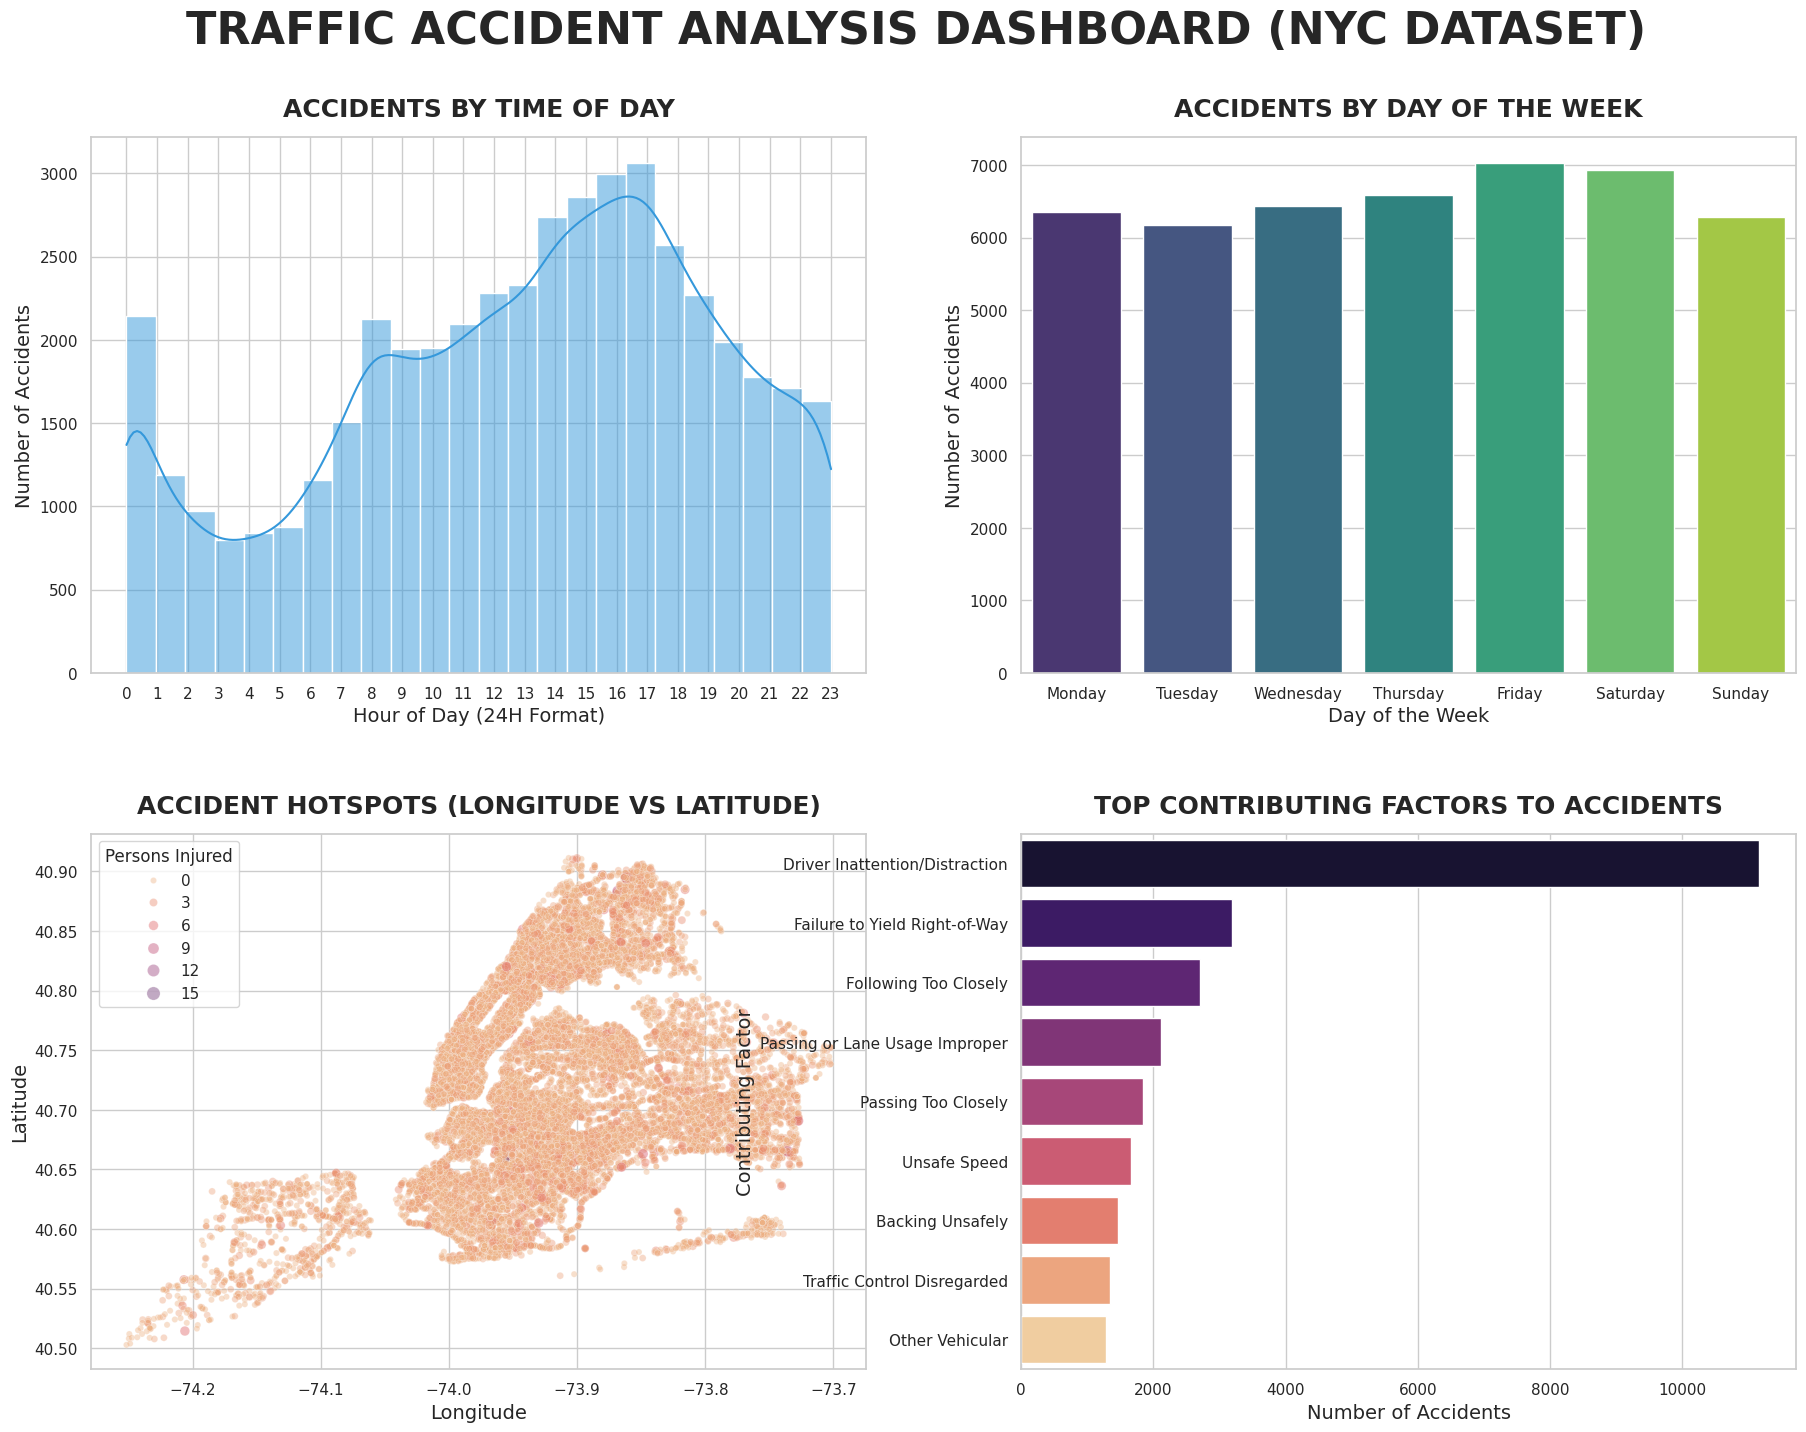

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# TASK 5: Traffic Accident Data Analysis
# Dataset: NYC Motor Vehicle Collisions (Live API URL)


def load_data(url):
    """Loads a subset of the traffic accidents dataset via direct URL."""
    print("Fetching traffic accident data from URL... (this may take a few seconds)")
    try:
        df = pd.read_csv(url)
        print("Dataset loaded successfully!")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_data(df):
    """Extracts temporal features and handles missing values for visualization."""
    print("Pre-processing data...")
    df_clean = df.copy()

    df_clean = df_clean.dropna(subset=['latitude', 'longitude'])

    df_clean['crash_datetime'] = pd.to_datetime(df_clean['crash_date'] + ' ' + df_clean['crash_time'], errors='coerce')

    df_clean['Hour'] = df_clean['crash_datetime'].dt.hour
    df_clean['DayOfWeek'] = df_clean['crash_datetime'].dt.day_name()

    df_clean = df_clean[(df_clean['latitude'] > 40.5) & (df_clean['latitude'] < 41.0)]
    df_clean = df_clean[(df_clean['longitude'] > -74.3) & (df_clean['longitude'] < -73.7)]

    return df_clean

def generate_dashboard(df):
    """Generates a multi-panel dashboard for accident patterns and hotspots."""
    print("Generating visualization dashboard...")

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(22, 16), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})
    fig.suptitle('TRAFFIC ACCIDENT ANALYSIS DASHBOARD (NYC DATASET)', fontsize=32, fontweight='bold', y=0.96)

    sns.histplot(df['Hour'].dropna(), bins=24, kde=True, color='#3498db', ax=axes[0, 0])
    axes[0, 0].set_title('ACCIDENTS BY TIME OF DAY', fontsize=18, fontweight='bold', pad=15)
    axes[0, 0].set_xlabel('Hour of Day (24H Format)', fontsize=14)
    axes[0, 0].set_ylabel('Number of Accidents', fontsize=14)
    axes[0, 0].set_xticks(range(0, 24))

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.countplot(data=df, x='DayOfWeek', order=days_order, palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title('ACCIDENTS BY DAY OF THE WEEK', fontsize=18, fontweight='bold', pad=15)
    axes[0, 1].set_xlabel('Day of the Week', fontsize=14)
    axes[0, 1].set_ylabel('Number of Accidents', fontsize=14)

    sample_df = df.sample(n=min(20000, len(df)), random_state=42)
    sns.scatterplot(x='longitude', y='latitude', data=sample_df,
                    hue='number_of_persons_injured', palette='flare',
                    size='number_of_persons_injured', sizes=(20, 100), alpha=0.4, ax=axes[1, 0])
    axes[1, 0].set_title('ACCIDENT HOTSPOTS (LONGITUDE VS LATITUDE)', fontsize=18, fontweight='bold', pad=15)
    axes[1, 0].set_xlabel('Longitude', fontsize=14)
    axes[1, 0].set_ylabel('Latitude', fontsize=14)
    axes[1, 0].legend(title='Persons Injured')

    # --- PANEL 4: Top Contributing Factors ---
    # The dataset uses 'contributing_factor_vehicle_1' for the primary cause of the accident
    factors = df['contributing_factor_vehicle_1'].value_counts().head(10)
    # Remove 'Unspecified' for better analytical insights
    if 'Unspecified' in factors:
        factors = factors.drop('Unspecified')

    sns.barplot(x=factors.values, y=factors.index, palette='magma', ax=axes[1, 1])
    axes[1, 1].set_title('TOP CONTRIBUTING FACTORS TO ACCIDENTS', fontsize=18, fontweight='bold', pad=15)
    axes[1, 1].set_xlabel('Number of Accidents', fontsize=14)
    axes[1, 1].set_ylabel('Contributing Factor', fontsize=14)

    plt.tight_layout()
    plt.show()

def main():
    url = 'https://data.cityofnewyork.us/resource/h9gi-nx95.csv?$limit=50000'

    df = load_data(url)

    if df is not None:
        processed_df = preprocess_data(df)
        generate_dashboard(processed_df)

if __name__ == "__main__":
    main()